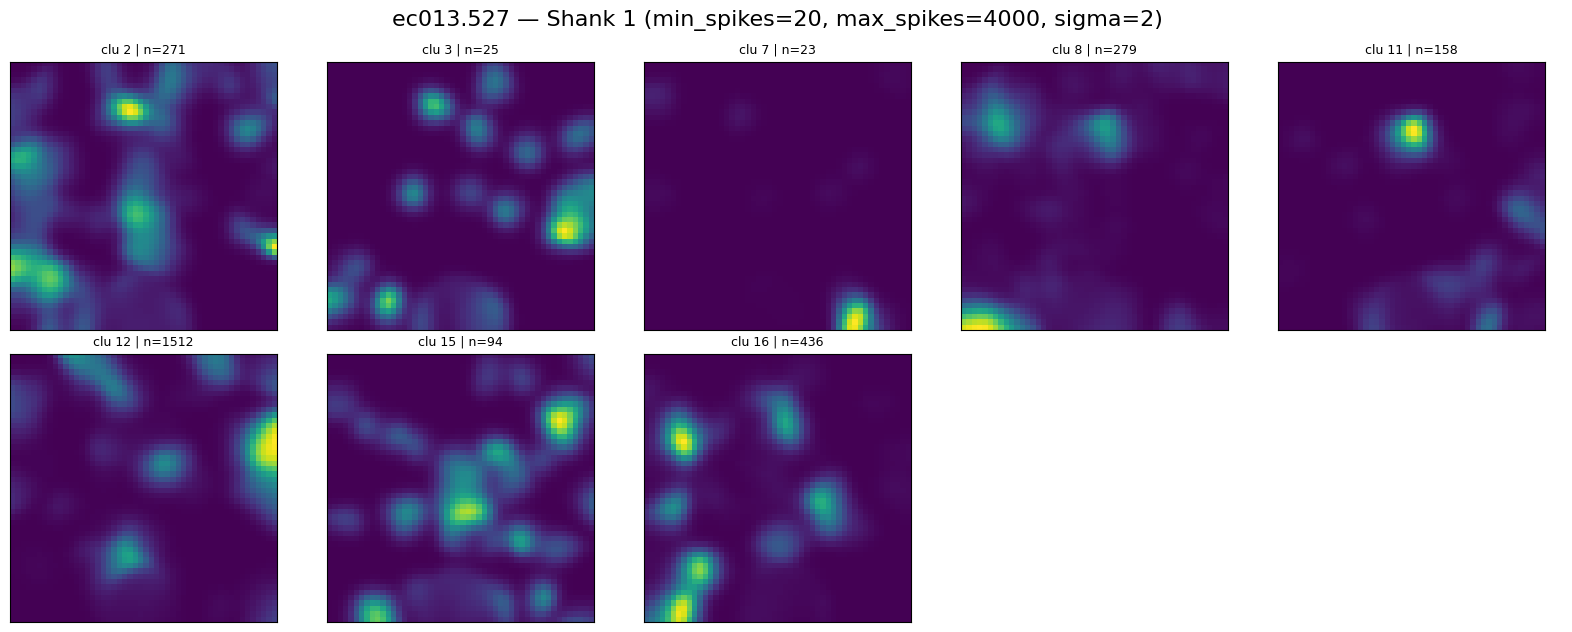

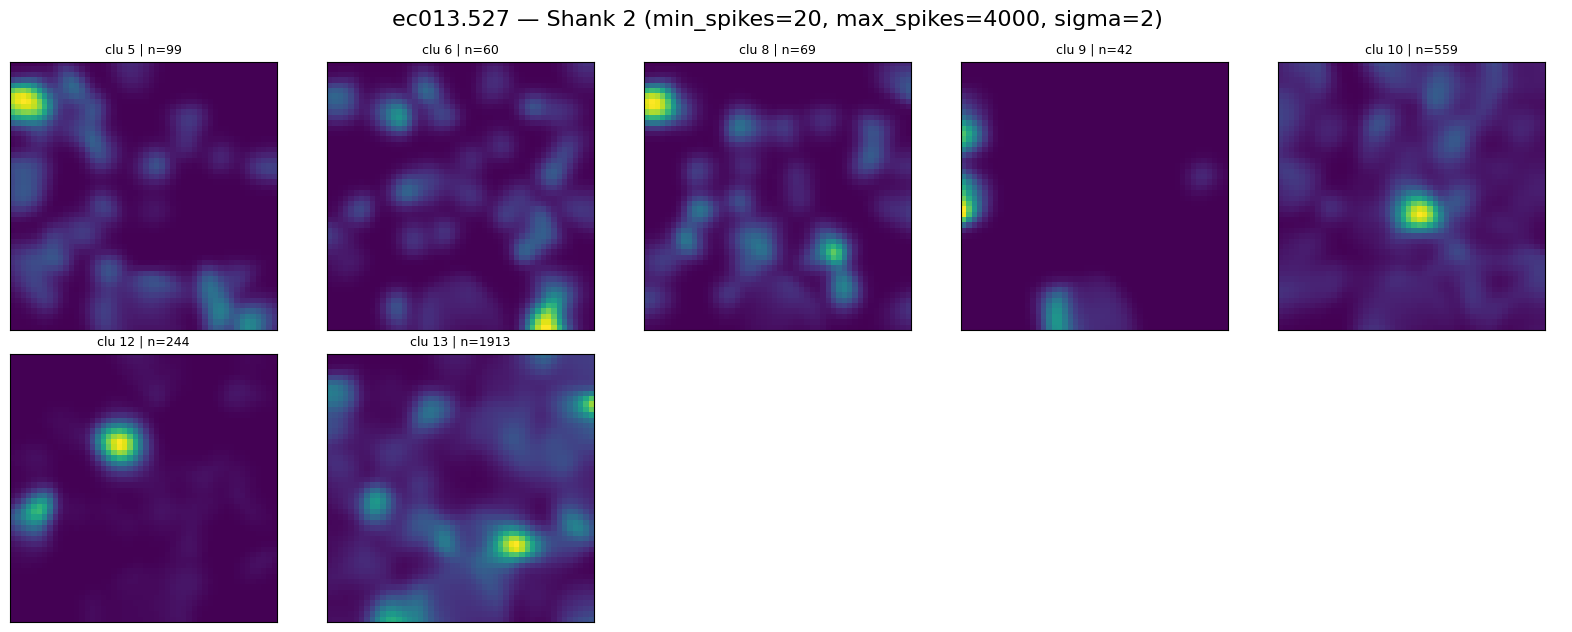

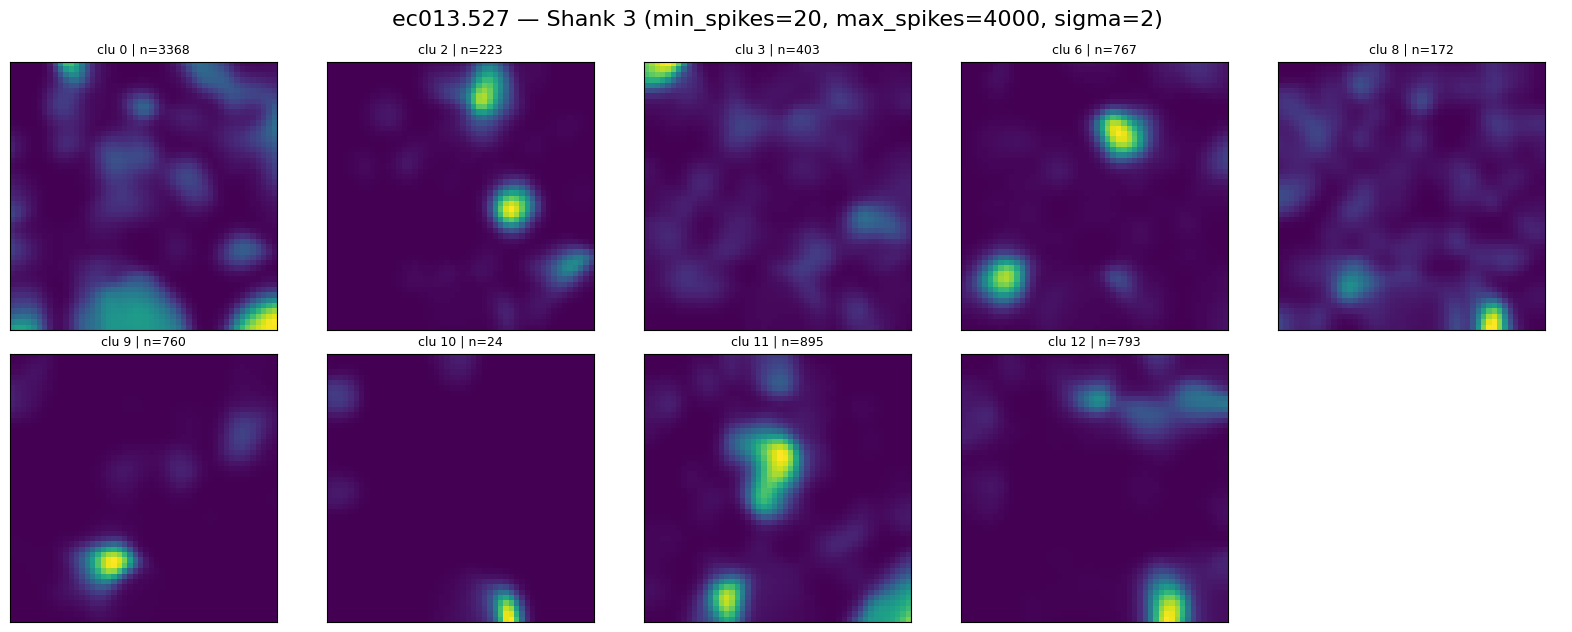

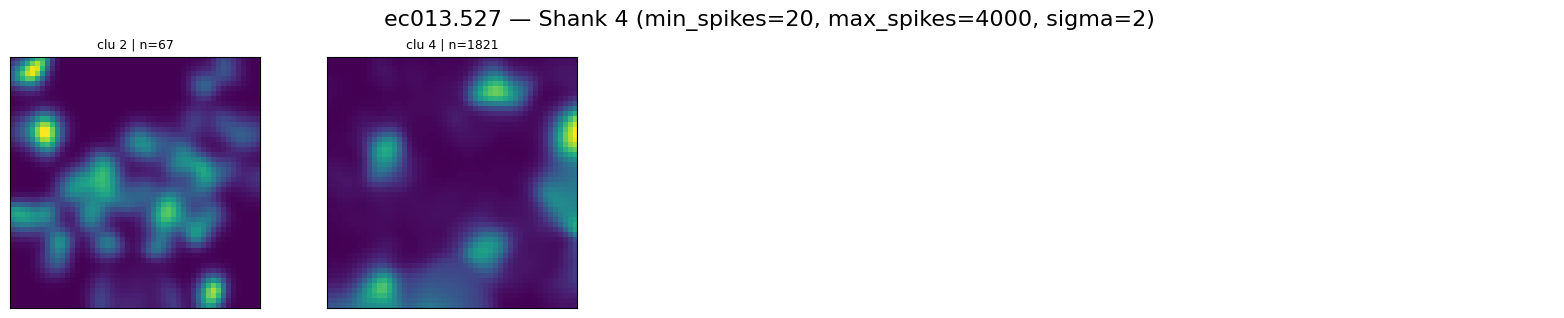

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import math
import glob
from scipy.ndimage import gaussian_filter

base = Path("/home/reilly/Desktop/hc2/ec013.527")
prefix = base.name[-10:]  # "ec013.527"
fs_spk = 20000.0                 # spike sample rate
fs_pos = 39.06                   # position rate (Hz)
dt = 1 / fs_pos

# --- load position (unmasked, keep valid mask for alignment) ---
whl = np.loadtxt(base / f"{prefix}.whl")
x0, y0 = whl[:, 0], whl[:, 1]
valid = (x0 >= 0) & (y0 >= 0)

x = x0[valid]
y = y0[valid]

def load_res_clu(shank: int):
    res = np.loadtxt(base / f"{prefix}.res.{shank}", dtype=int)
    clu = np.loadtxt(base / f"{prefix}.clu.{shank}", dtype=int)
    n_units = int(clu[0])
    clu = clu[1:]
    return res, clu, n_units

def spikes_to_pos_idx(res_samples):
    # res_samples are at 20kHz; map to position samples at 39.06Hz
    spk_t = res_samples / fs_spk
    spk_idx = (spk_t / dt).astype(int)
    # keep only indices in range and with valid tracking
    ok = (spk_idx >= 0) & (spk_idx < len(x0)) & valid[spk_idx]
    return spk_idx[ok]

def plot_shank(shank: int, min_spikes=20, max_spikes=None, sigma=1.5, bins=50):

    res, clu, n_units = load_res_clu(shank)
    if max_spikes is None:
        max_spikes = np.inf
    units = range(n_units)

    # collect units with enough spikes
    unit_data = []
    for u in units:
        res_u = res[clu == u]
        if len(res_u) >= min_spikes and len(res_u) <= max_spikes:
            unit_data.append((u, res_u))

    if not unit_data:
        print(f"Shank {shank}: no units with >= {min_spikes} spikes and <= {max_spikes} spikes.")
        return

    # define spatial bins over valid position range
    xedges = np.linspace(np.min(x), np.max(x), bins + 1)
    yedges = np.linspace(np.min(y), np.max(y), bins + 1)

    # occupancy histogram (seconds per bin), then smooth
    occ_counts, _, _ = np.histogram2d(x, y, bins=[xedges, yedges])
    occ_time = occ_counts * dt
    occ_smooth = gaussian_filter(occ_time, sigma=sigma, mode='constant')

    n = len(unit_data)
    cols = 5
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(3.2*cols, 3.2*rows), squeeze=False)
    fig.suptitle(f"{prefix} — Shank {shank} (min_spikes={min_spikes}, max_spikes={max_spikes}, sigma={sigma})", fontsize=16)

    for ax in axes.ravel():
        ax.set_axis_off()

    for i, (u, res_u) in enumerate(unit_data):
        ax = axes.ravel()[i]
        ax.set_axis_on()

        # spike positions and firing histogram
        spk_idx = spikes_to_pos_idx(res_u)
        spk_x = x0[spk_idx]
        spk_y = y0[spk_idx]
        spk_counts, _, _ = np.histogram2d(spk_x, spk_y, bins=[xedges, yedges])
        spk_smooth = gaussian_filter(spk_counts, sigma=sigma, mode='constant')

        # rate map: smooth(spikes) / smooth(occupancy)
        rate = np.divide(spk_smooth, occ_smooth, out=np.zeros_like(spk_smooth), where=occ_smooth > 0)

        im = ax.imshow(
            rate.T,
            origin='lower',
            extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
            cmap='viridis',
            aspect='equal',
        )
        ax.set_title(f"clu {u} | n={len(res_u)}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout()
    plt.show()

# --- find available shanks automatically ---
clu_files = sorted(glob.glob(str(base / f"{prefix}.clu.*")))
shanks = sorted({int(Path(f).suffix.split('.')[-1]) for f in clu_files})

for sh in shanks:
    plot_shank(sh, min_spikes=20, max_spikes=4_000, sigma=2)

# If you want to see the "noise/MUA" cluster too, run:
# plot_shank(1, min_spikes=200)
